# Data Preprocessing

## References

- [League of Legends Win Analysis - Medium Article](https://zijiemei.medium.com/league-of-legends-win-analysis-ff6310152430)

- [The Win Probability metric employed by Riot Games - Reddit](https://www.reddit.com/r/leagueoflegends/comments/19e91me/training_machine_learning_models_to_predict/)

## Imports

In [1]:
%pip install pandas scikit-learn matplotlib seaborn numpy

# Imports
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


Note: you may need to restart the kernel to use updated packages.


## Load CSV data set and create DataFrames

In [2]:
def transform_csv_to_dataframe(folder_path):
    """
    Transforms raw CSV files into a single dataset.

    Params:
        folder_path (str): The path to the folder containing the CSV files.

    Returns:
        (pd.DataFrame): The transformed dataset.
    """
    # Get all CSV files in the folder
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    # Initialize an empty list to store the dataframes
    dataframes = []

    # Load each CSV file into a dataframe and append it to the list
    for csv_file in csv_files:
        df = pd.read_csv(os.path.join(folder_path, csv_file))
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_df = pd.concat(dataframes, ignore_index=True)

    return combined_df


df_challenger = transform_csv_to_dataframe('challengerleagues/')

In [3]:
df_challenger.head()

,timestamp,soul,1.champion,2.champion,3.champion,4.champion,5.champion,6.champion,7.champion,8.champion,...,RED.ELDER_DRAGON.kills,RED.RIFTHERALD.kills,RED.BARON_NASHOR.kills,RED.HORDE.kills,RED.ATAKHAN.kills,BLUE.TOWER_BUILDING.kills,RED.TOWER_BUILDING.kills,BLUE.INHIBITOR_BUILDING.kills,RED.INHIBITOR_BUILDING.kills,winner
0,0,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
1,60017,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
2,120046,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
3,180116,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
4,240131,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE


In [4]:
df_challenger.isnull().sum()

timestamp                             0
soul                             302410
1.champion                            0
2.champion                            0
3.champion                            0
                                  ...  
BLUE.TOWER_BUILDING.kills             0
RED.TOWER_BUILDING.kills              0
BLUE.INHIBITOR_BUILDING.kills         0
RED.INHIBITOR_BUILDING.kills          0
winner                                0
Length: 109, dtype: int64

## Winner Feature Encoding

*- BLUE: 0*

*- RED: 1*

In [5]:
# Initialize the label encoder
le = LabelEncoder()

# Fit and transform the 'winner' column
df_challenger['winner'] = le.fit_transform(df_challenger['winner'])

# BLUE: 0, RED: 1
df_challenger[['winner']].head()

,winner
0,0
1,0
2,0
3,0
4,0


## General Features Encoding

In [6]:
print(df_challenger.columns)

Index(['timestamp', 'soul', '1.champion', '2.champion', '3.champion',
       '4.champion', '5.champion', '6.champion', '7.champion', '8.champion',
       ...
       'RED.ELDER_DRAGON.kills', 'RED.RIFTHERALD.kills',
       'RED.BARON_NASHOR.kills', 'RED.HORDE.kills', 'RED.ATAKHAN.kills',
       'BLUE.TOWER_BUILDING.kills', 'RED.TOWER_BUILDING.kills',
       'BLUE.INHIBITOR_BUILDING.kills', 'RED.INHIBITOR_BUILDING.kills',
       'winner'],
      dtype='object', length=109)


In [7]:
df_challenger.dtypes

timestamp                         int64
soul                             object
1.champion                        int64
2.champion                        int64
3.champion                        int64
                                  ...  
BLUE.TOWER_BUILDING.kills         int64
RED.TOWER_BUILDING.kills          int64
BLUE.INHIBITOR_BUILDING.kills     int64
RED.INHIBITOR_BUILDING.kills      int64
winner                            int64
Length: 109, dtype: object

In [8]:
df_challenger['soul'].unique()

array([nan, 'Mountain', 'Hextech', 'Infernal', 'Ocean', 'Chemtech',
       'Cloud'], dtype=object)

In [9]:
# One-hot encode the 'soul' feature
df_challenger = pd.get_dummies(df_challenger, columns=['soul'], prefix='soul')

# Convert boolean columns to integers
boolean_columns = df_challenger.select_dtypes(include='bool').columns
df_challenger[boolean_columns] = df_challenger[boolean_columns].astype(int)

# Display the first few rows of the updated dataframe
df_challenger.head()

,timestamp,1.champion,2.champion,3.champion,4.champion,5.champion,6.champion,7.champion,8.champion,9.champion,...,RED.TOWER_BUILDING.kills,BLUE.INHIBITOR_BUILDING.kills,RED.INHIBITOR_BUILDING.kills,winner,soul_Chemtech,soul_Cloud,soul_Hextech,soul_Infernal,soul_Mountain,soul_Ocean
0,0,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
1,60017,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
2,120046,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
3,180116,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
4,240131,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0


## Feature Selection

This is the correlation matrix of the actuel features:

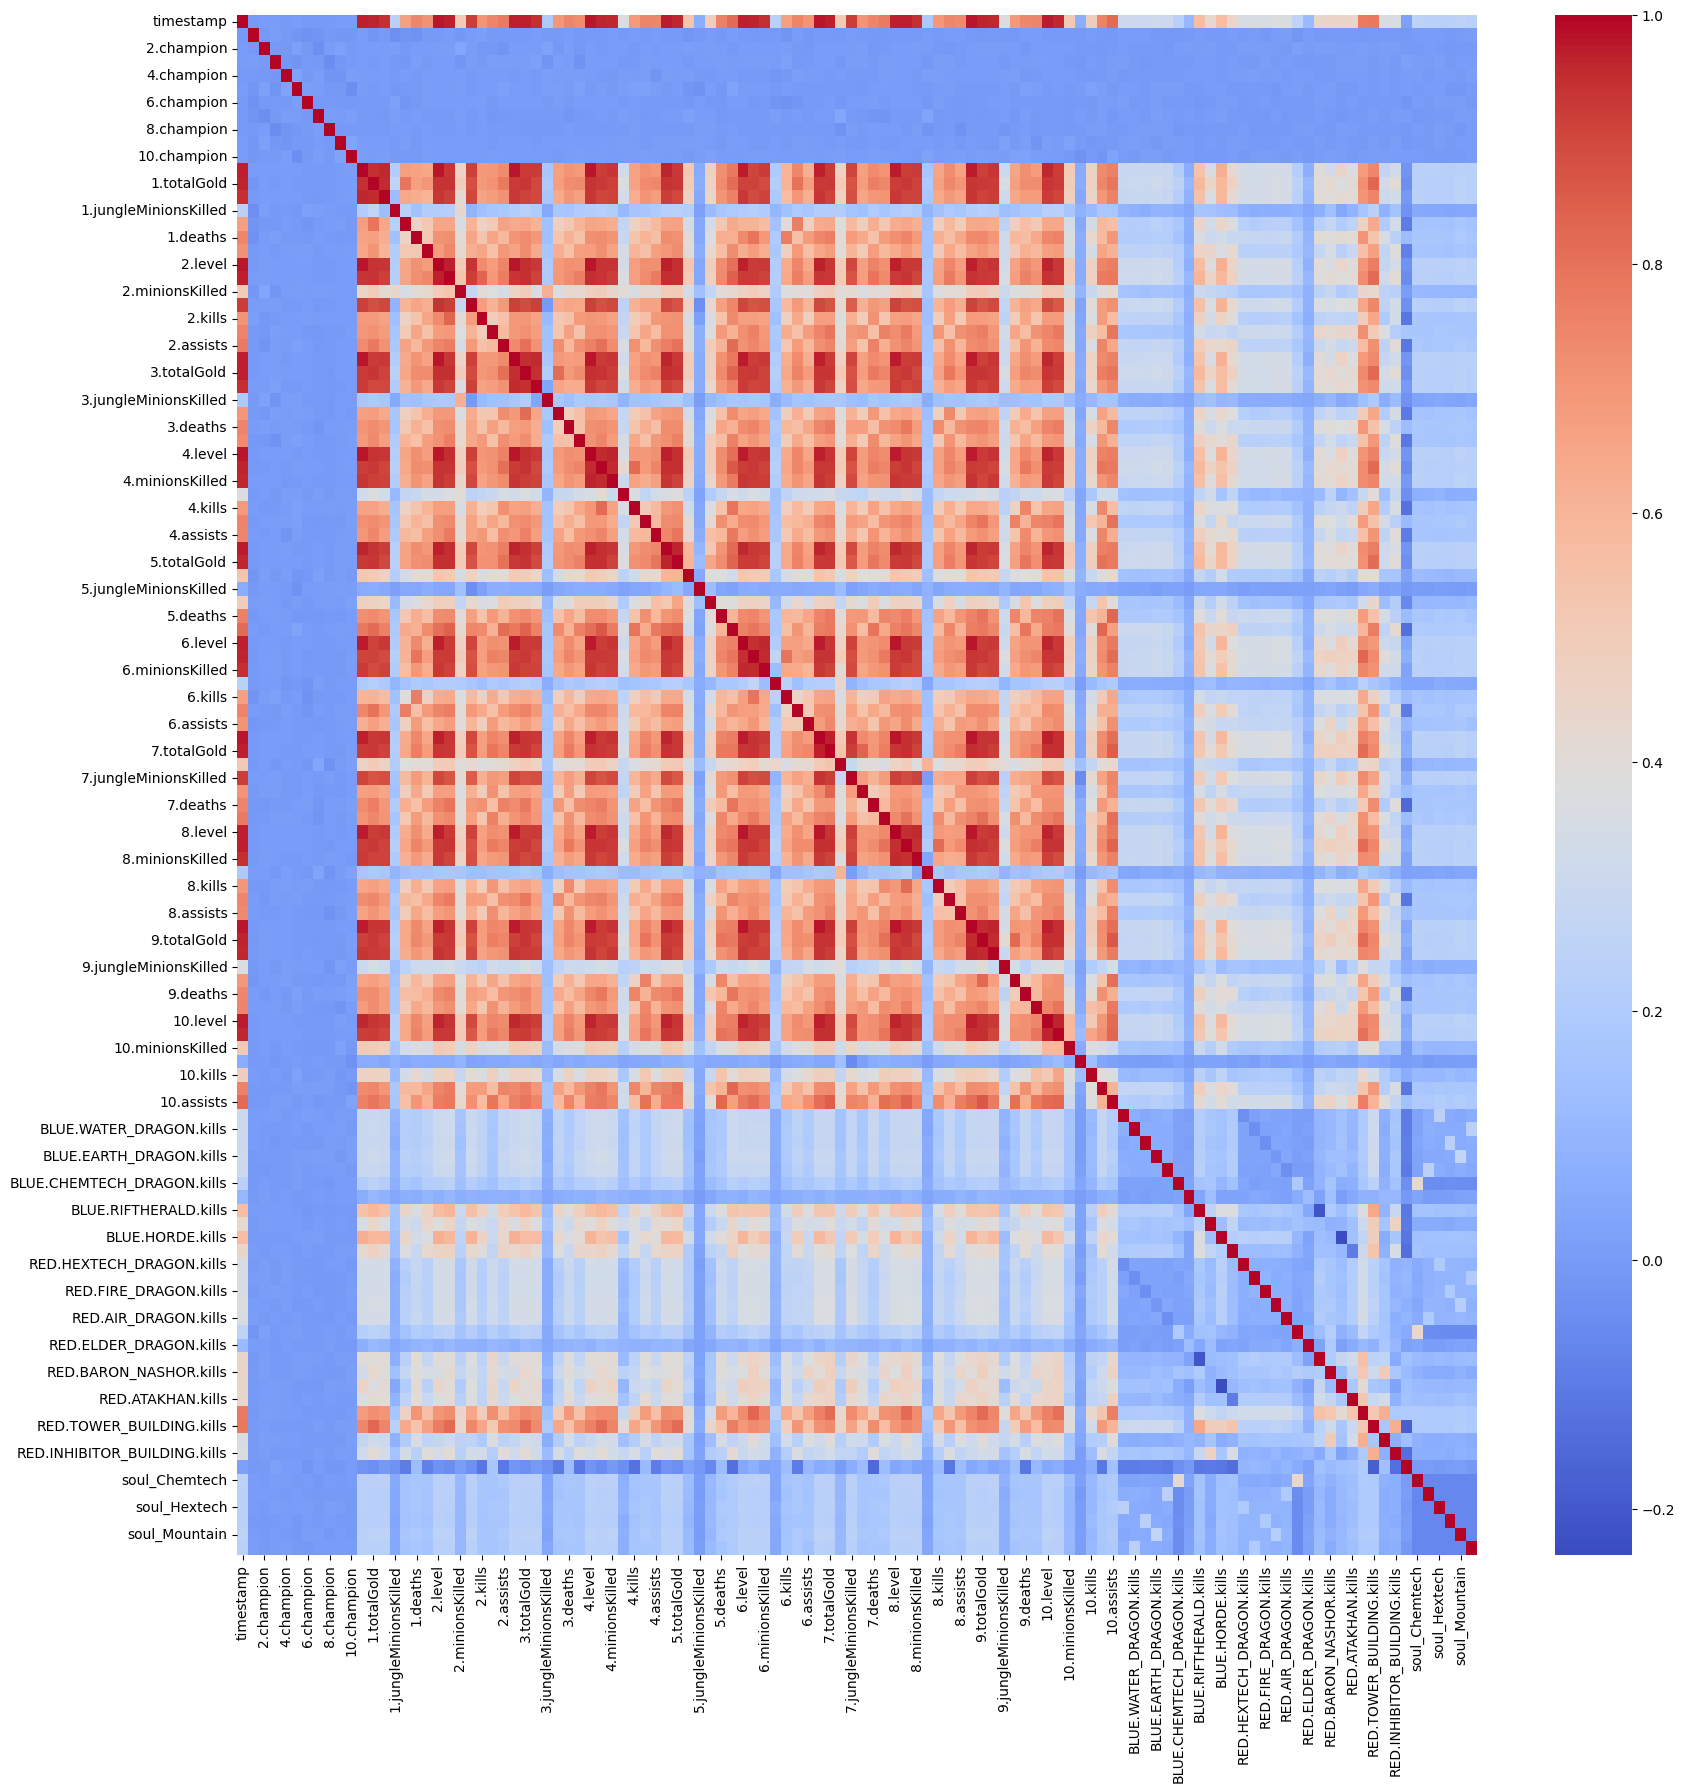

In [10]:
# Calculate the correlation matrix
correlation_matrix = df_challenger.corr()

# Set the size of the plot
plt.figure(figsize=(20, 20))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

### Team features

We will create new features that represent the mean of the features of the two teams. This will allow us to have a more general idea of the game and reduce dimensionality.

In [11]:
# # Level
# df_challenger['BLUE.mean_level'] = df_challenger[['1.level', '2.level', '3.level', '4.level', '5.level']].mean(axis=1)
# df_challenger['RED.mean_level'] = df_challenger[['6.level', '7.level', '8.level', '9.level', '10.level']].mean(axis=1)

# df_challenger.drop(['1.level', '2.level', '3.level', '4.level', '5.level', '6.level', '7.level', '8.level', '9.level', '10.level'], axis=1, inplace=True)

# # Total Gold
# df_challenger['BLUE.mean_totalGold'] = df_challenger[['1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold']].mean(axis=1)
# df_challenger['RED.mean_totalGold'] = df_challenger[['6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold']].mean(axis=1)

# df_challenger.drop(['1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold', '6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold'], axis=1, inplace=True)

# # Minions Killed
# df_challenger['BLUE.mean_minionsKilled'] = df_challenger[['1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled']].mean(axis=1)
# df_challenger['RED.mean_minionsKilled'] = df_challenger[['6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled']].mean(axis=1)

# df_challenger.drop(['1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled', '6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'], axis=1, inplace=True)

# # Jungle Minions Killed
# df_challenger['BLUE.mean_jungleMinionsKilled'] = df_challenger[['1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled']].mean(axis=1)
# df_challenger['RED.mean_jungleMinionsKilled'] = df_challenger[['6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled']].mean(axis=1)

# df_challenger.drop(['1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled', '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled'], axis=1, inplace=True)

# Summation for Blue Team (champions IDs 1..5)
df_challenger['BLUE.level'] = df_challenger[['1.level', '2.level', '3.level', '4.level', '5.level']].sum(axis=1)
df_challenger['BLUE.kills'] = df_challenger[['1.kills', '2.kills', '3.kills', '4.kills', '5.kills']].sum(axis=1)
df_challenger['BLUE.deaths'] = df_challenger[['1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths']].sum(axis=1)
df_challenger['BLUE.assists'] = df_challenger[['1.assists', '2.assists', '3.assists', '4.assists', '5.assists']].sum(axis=1)
df_challenger['BLUE.totalGold'] = df_challenger[['1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold']].sum(axis=1)
df_challenger['BLUE.minionsKilled'] = df_challenger[['1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                                                     , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled']].sum(axis=1)
df_challenger.drop(['1.kills', '2.kills', '3.kills', '4.kills', '5.kills', '1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths', '1.assists', '2.assists', '3.assists', '4.assists', '5.assists',
                     '1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold' , '1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                    , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled'
                    , '1.level', '2.level', '3.level', '4.level', '5.level' ], axis=1, inplace=True)

# Summation for Red Team (champions IDs 6..10)
df_challenger['RED.level'] = df_challenger[['6.level', '7.level', '8.level', '9.level', '10.level']].sum(axis=1)
df_challenger['RED.kills'] = df_challenger[['6.kills', '7.kills', '8.kills', '9.kills', '10.kills']].sum(axis=1)
df_challenger['RED.deaths'] = df_challenger[['6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths']].sum(axis=1)
df_challenger['RED.assists'] = df_challenger[['6.assists', '7.assists', '8.assists', '9.assists', '10.assists']].sum(axis=1)
df_challenger['RED.totalGold'] = df_challenger[['6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold']].sum(axis=1)
df_challenger['RED.minionsKilled'] = df_challenger[['6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                                                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled']].sum(axis=1)
df_challenger.drop(['6.kills', '7.kills', '8.kills', '9.kills', '10.kills', '6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths', '6.assists', '7.assists', '8.assists', '9.assists', '10.assists'
                    , '6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold', '6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled'
                    , '6.level', '7.level', '8.level', '9.level', '10.level' ], axis=1, inplace=True)


### KDA features -> BAD IDEA

Create KDA feature for each player grouping kills, deaths and assists.

In [12]:
# df_challenger['1.kda'] = (df_challenger['1.kills'] + df_challenger['1.assists']) / df_challenger['1.deaths']
# df_challenger['2.kda'] = (df_challenger['2.kills'] + df_challenger['2.assists']) / df_challenger['2.deaths']
# df_challenger['3.kda'] = (df_challenger['3.kills'] + df_challenger['3.assists']) / df_challenger['3.deaths']
# df_challenger['4.kda'] = (df_challenger['4.kills'] + df_challenger['4.assists']) / df_challenger['4.deaths']
# df_challenger['5.kda'] = (df_challenger['5.kills'] + df_challenger['5.assists']) / df_challenger['5.deaths']
# df_challenger['6.kda'] = (df_challenger['6.kills'] + df_challenger['6.assists']) / df_challenger['6.deaths']
# df_challenger['7.kda'] = (df_challenger['7.kills'] + df_challenger['7.assists']) / df_challenger['7.deaths']
# df_challenger['8.kda'] = (df_challenger['8.kills'] + df_challenger['8.assists']) / df_challenger['8.deaths']
# df_challenger['9.kda'] = (df_challenger['9.kills'] + df_challenger['9.assists']) / df_challenger['9.deaths']
# df_challenger['10.kda'] = (df_challenger['10.kills'] + df_challenger['10.assists']) / df_challenger['10.deaths']

# df_challenger.drop(['1.kills', '2.kills', '3.kills', '4.kills', '5.kills', '6.kills', '7.kills', '8.kills', '9.kills'
# , '10.kills', '1.assists', '2.assists', '3.assists', '4.assists', '5.assists', '6.assists', '7.assists', '8.assists'
# , '9.assists', '10.assists', '1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths', '6.deaths', '7.deaths', '8.deaths'
# , '9.deaths', '10.deaths'], axis=1, inplace=True)

### Drop champion features

Drop these features for the moment. Looking to find a way to encode them or use them in a different way.

In [13]:
df_challenger.drop(['1.champion', '2.champion', '3.champion', '4.champion', '5.champion', '6.champion', '7.champion', '8.champion', '9.champion', '10.champion'], axis=1, inplace=True)

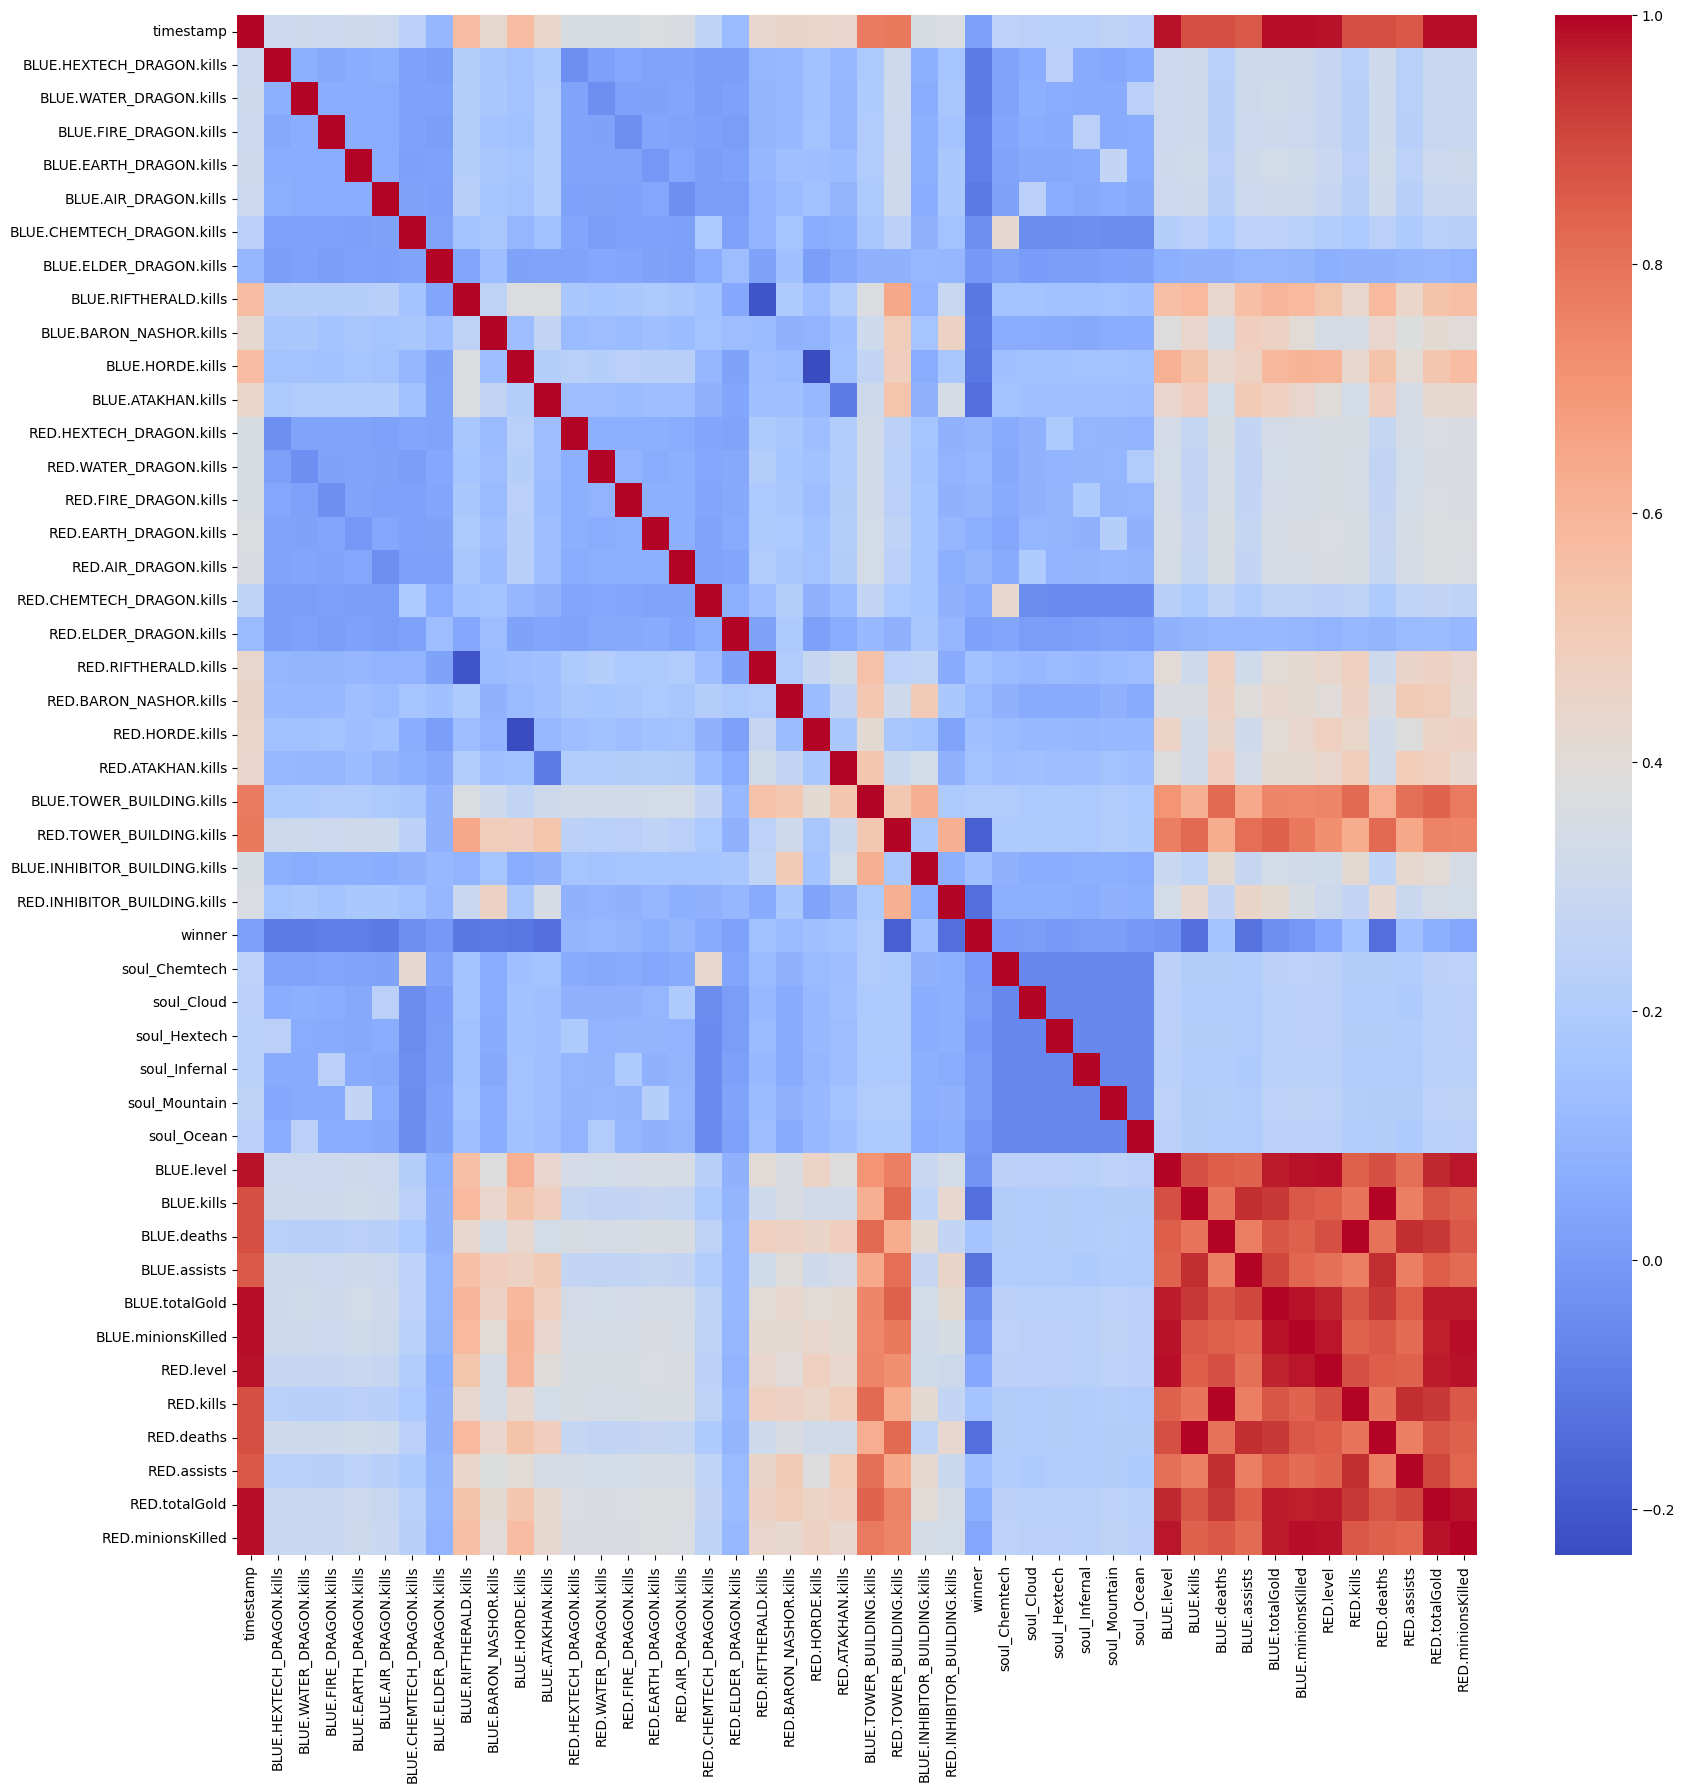

In [14]:
# Calculate the correlation matrix
correlation_matrix = df_challenger.corr()

# Set the size of the plot
plt.figure(figsize=(20, 20))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

There are strong correlations between the features of the two teams.

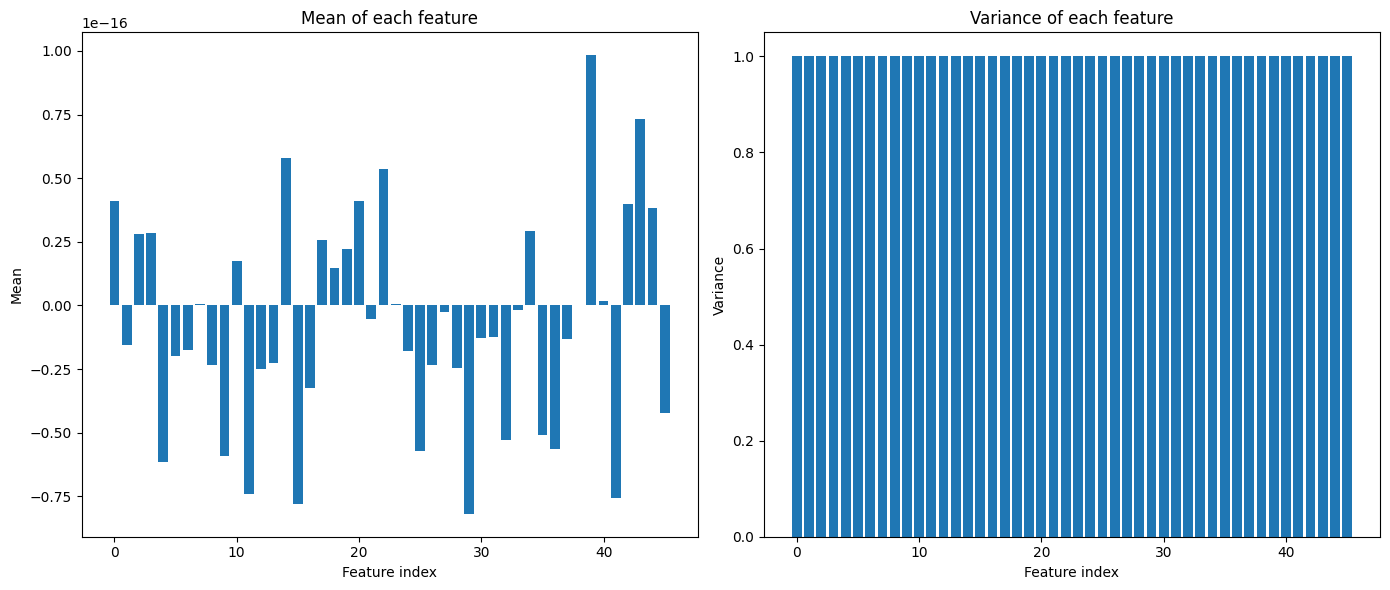

In [15]:
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_challenger)

# Calculate mean and variance for each feature
means = np.mean(scaled_data, axis=0)
variances = np.var(scaled_data, axis=0)

# Plot mean and variance
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(range(len(means)), means)
plt.title('Mean of each feature')
plt.xlabel('Feature index')
plt.ylabel('Mean')

plt.subplot(1, 2, 2)
plt.bar(range(len(variances)), variances)
plt.title('Variance of each feature')
plt.xlabel('Feature index')
plt.ylabel('Variance')

plt.tight_layout()
plt.show()